In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime
import os
import seaborn as sns

In [3]:
directory = 'D:/BIOAKUSTIK/DETECTOR SPECIES/5_VERIFICATION/SUAQ BALIMBING/' #Langkah pertama menyatukan semua deteksi

In [22]:
species = 'LARGIBBON' #ganti nama target suara, seperti gibbon, chainsaw, dan siamang
positive_or_negative = 'Positive' #tinggal ganti menjadi positif dan negatif sesuai dengan kebutuhan
class_subfolders = {'LARGIBBON': 'Gibbon', 'SIAMANG': 'Siamang', 'CHAINSAW': 'Chainsaw'}

In [23]:
all_data = []
deployments = os.listdir(directory + species)

# loop through all deployments
for deployment in deployments:
    print('----------------------------------')
    print(deployment)
    
    data_folder = directory + '/' + species + '/' + deployment + '/' + class_subfolders[species] + '/' + positive_or_negative + '/'

    print('\t' + data_folder + ': ' + str(len(os.listdir(data_folder))) + ' files')

    for file in os.listdir(data_folder):
        if file.endswith('.wav'):
            conf, index, unit, date, time, start_offset, end_offset = file.split('_')
            
            # read in date and time, and properly format
            date = datetime.datetime.strptime(date, '%Y%m%d')
            time = datetime.datetime.strptime(time, '%H%M%S')

            # make a datetime with the correct offset
            date_time = date.replace(hour=time.hour, minute=time.minute, second=time.second)

            # add the time offset to the current datetime
            start_time = date_time + datetime.timedelta(seconds=float(start_offset[:-1]))
            end_time = date_time + datetime.timedelta(seconds=float(end_offset[:-5]))

            # turn confidence value into a number
            conf = float(conf)

            # put this all into a dictionary
            data = {'Species': species, 'Deployment': deployment, 'Unit': unit, 'Filename': file, 'Date': date, 'Start Time': start_time, 'End Time': end_time, 'Confidence': conf, 'Positive or Negative': positive_or_negative}
            
            # add all of this to the overall dataset
            all_data.append(data)

# combine all deployments into one large data frame
all_data = pd.DataFrame(all_data)
            

----------------------------------
DEPLOYMENT 6
	D:/BIOAKUSTIK/DETECTOR SPECIES/5_VERIFICATION/SUAQ BALIMBING//SIAMANG/DEPLOYMENT 6/Siamang/Positive/: 186 files
----------------------------------
DEPLOYMENT 7
	D:/BIOAKUSTIK/DETECTOR SPECIES/5_VERIFICATION/SUAQ BALIMBING//SIAMANG/DEPLOYMENT 7/Siamang/Positive/: 2 files
----------------------------------
DEPLOYMENT 8
	D:/BIOAKUSTIK/DETECTOR SPECIES/5_VERIFICATION/SUAQ BALIMBING//SIAMANG/DEPLOYMENT 8/Siamang/Positive/: 110 files
----------------------------------
DEPLYOMENT 9
	D:/BIOAKUSTIK/DETECTOR SPECIES/5_VERIFICATION/SUAQ BALIMBING//SIAMANG/DEPLYOMENT 9/Siamang/Positive/: 0 files


In [24]:
all_data

,Species,Deployment,Unit,Filename,Date,Start Time,End Time,Confidence,Positive or Negative
0,SIAMANG,DEPLOYMENT 6,Suaq01,0.110_15_Suaq01_20241229_012001_2352.0s_2355.0...,2024-12-29,2024-12-29 01:59:13,2024-12-29 01:59:16,0.110,Positive
1,SIAMANG,DEPLOYMENT 6,Suaq01,0.160_22_Suaq01_20241229_012001_2193.0s_2196.0...,2024-12-29,2024-12-29 01:56:34,2024-12-29 01:56:37,0.160,Positive
2,SIAMANG,DEPLOYMENT 6,Suaq01,0.174_19_Suaq01_20241229_012001_2154.0s_2157.0...,2024-12-29,2024-12-29 01:55:55,2024-12-29 01:55:58,0.174,Positive
3,SIAMANG,DEPLOYMENT 6,Suaq01,0.179_21_Suaq01_20241229_012001_2568.0s_2571.0...,2024-12-29,2024-12-29 02:02:49,2024-12-29 02:02:52,0.179,Positive
4,SIAMANG,DEPLOYMENT 6,Suaq01,0.187_20_Suaq01_20241229_012001_2325.0s_2328.0...,2024-12-29,2024-12-29 01:58:46,2024-12-29 01:58:49,0.187,Positive
...,...,...,...,...,...,...,...,...,...
293,SIAMANG,DEPLOYMENT 8,Suaq01,1.000_46_Suaq01_20250416_012001_132.0s_135.0s.wav,2025-04-16,2025-04-16 01:22:13,2025-04-16 01:22:16,1.000,Positive
294,SIAMANG,DEPLOYMENT 8,Suaq01,1.000_51_Suaq01_20250416_012001_111.0s_114.0s.wav,2025-04-16,2025-04-16 01:21:52,2025-04-16 01:21:55,1.000,Positive
295,SIAMANG,DEPLOYMENT 8,Suaq01,1.000_53_Suaq01_20250416_012001_162.0s_165.0s.wav,2025-04-16,2025-04-16 01:22:43,2025-04-16 01:22:46,1.000,Positive
296,SIAMANG,DEPLOYMENT 8,Suaq01,1.000_7_Suaq01_20250416_012001_129.0s_132.0s.wav,2025-04-16,2025-04-16 01:22:10,2025-04-16 01:22:13,1.000,Positive


In [24]:
all_data[all_data['Unit'] == 'Suaq01']

,Species,Deployment,Unit,Filename,Date,Start Time,End Time,Confidence,Positive or Negative
0,SIAMANG,DEPLOYMENT 6,Suaq01,0.100_1_Suaq01_20241216_200007_1458.0s_1461.0s...,2024-12-16,2024-12-16 20:24:25,2024-12-16 20:24:28,0.100,Negative
1,SIAMANG,DEPLOYMENT 6,Suaq01,0.116_1_Suaq01_20241212_000000_0.0s_3.0s.wav,2024-12-12,2024-12-12 00:00:00,2024-12-12 00:00:03,0.116,Negative
2,SIAMANG,DEPLOYMENT 6,Suaq01,0.131_1_Suaq01_20241225_064003_3915.0s_3918.0s...,2024-12-25,2024-12-25 07:45:18,2024-12-25 07:45:21,0.131,Negative
3,SIAMANG,DEPLOYMENT 6,Suaq01,0.146_1_Suaq01_20241230_000000_3249.0s_3252.0s...,2024-12-30,2024-12-30 00:54:09,2024-12-30 00:54:12,0.146,Negative
15,SIAMANG,DEPLOYMENT 6,Suaq01,0.278_1_Suaq01_20241226_000000_0.0s_3.0s.wav,2024-12-26,2024-12-26 00:00:00,2024-12-26 00:00:03,0.278,Negative
17,SIAMANG,DEPLOYMENT 6,Suaq01,0.279_1_Suaq01_20241213_000000_0.0s_3.0s.wav,2024-12-13,2024-12-13 00:00:00,2024-12-13 00:00:03,0.279,Negative
20,SIAMANG,DEPLOYMENT 6,Suaq01,0.283_1_Suaq01_20241226_024001_1659.0s_1662.0s...,2024-12-26,2024-12-26 03:07:40,2024-12-26 03:07:43,0.283,Negative
38,SIAMANG,DEPLOYMENT 6,Suaq01,0.336_1_Suaq01_20241220_040002_3345.0s_3348.0s...,2024-12-20,2024-12-20 04:55:47,2024-12-20 04:55:50,0.336,Negative
47,SIAMANG,DEPLOYMENT 6,Suaq01,0.374_1_Suaq01_20241229_040002_4230.0s_4233.0s...,2024-12-29,2024-12-29 05:10:32,2024-12-29 05:10:35,0.374,Negative


In [11]:
save_directory = 'D:/BIOAKUSTIK/DETECTOR SPECIES/5_VERIFICATION/SUAQ BALIMBING/'
all_data.to_csv(save_directory + species + '_' + positive_or_negative + '_detections.csv')

In [12]:
#UNTUK MELIHAT GABUNGAN, tinggal diganti menjadi Siamang dan Gibbon
positive_data = pd.read_csv('D:/BIOAKUSTIK/DETECTOR SPECIES/5_VERIFICATION/SUAQ BALIMBING/SIAMANG_Positive_detections.csv') 
negative_data = pd.read_csv('D:/BIOAKUSTIK/DETECTOR SPECIES/5_VERIFICATION/SUAQ BALIMBING/SIAMANG_Negative_detections.csv')

<Axes: xlabel='count', ylabel='Date'>

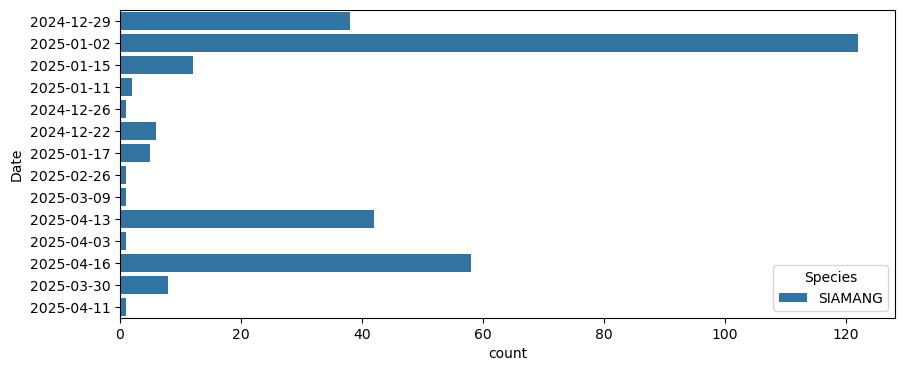

In [25]:
plt.figure(figsize=(10, 4)) #ingin melihat grafik 
sns.countplot(data=all_data, hue= 'Species', y='Date')

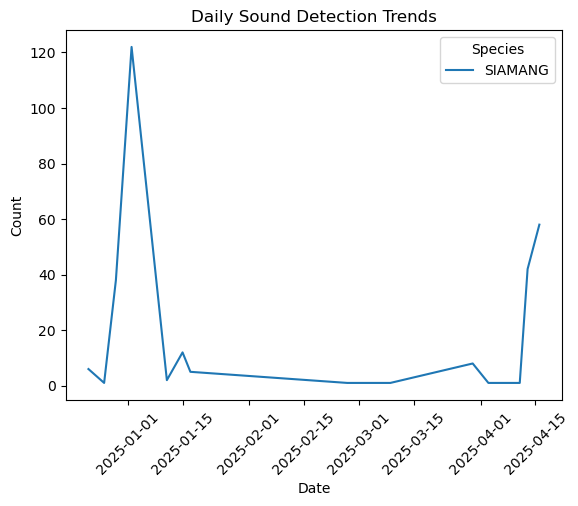

In [26]:
all_data['Date'] = pd.to_datetime(all_data['Start Time']).dt.date
daily_counts = all_data.groupby(['Date', 'Species']).size().reset_index(name='Count')
sns.lineplot(data=daily_counts, x='Date', y='Count', hue='Species')
plt.title("Daily Sound Detection Trends")
plt.xticks(rotation=45)
plt.show()

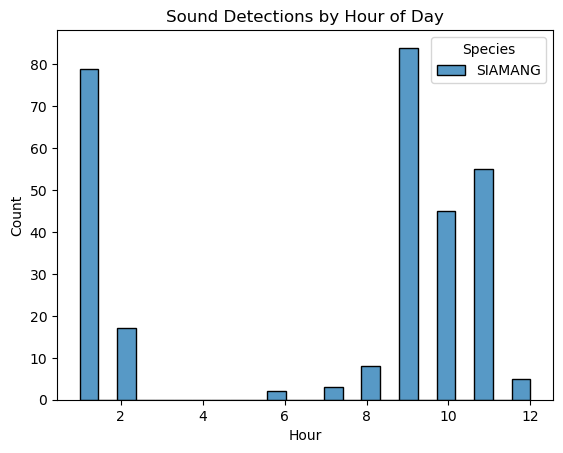

In [27]:
all_data['Hour'] = pd.to_datetime(all_data['Start Time']).dt.hour
sns.histplot(data=all_data, x='Hour', hue='Species', multiple='stack', bins=24)
plt.title("Sound Detections by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.show()

In [16]:
all_data = pd.concat((positive_data, negative_data))

<Axes: xlabel='count', ylabel='Date'>

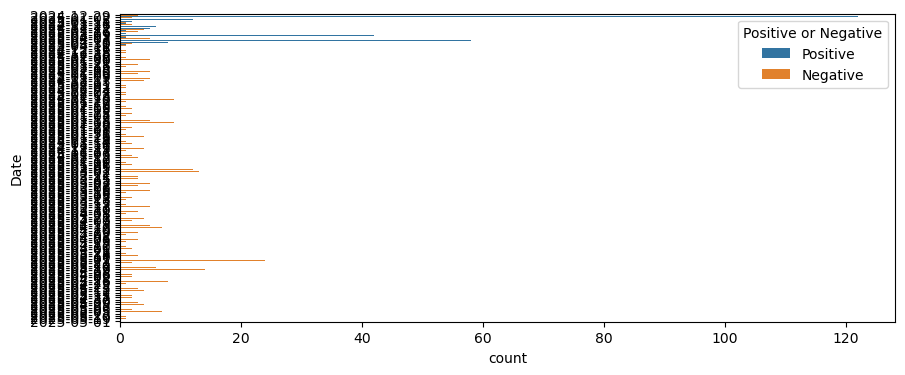

In [17]:
plt.figure(figsize=(10, 4)) #ingin melihat grafik yang negatif dan positif
sns.countplot(data=all_data, hue= 'Positive or Negative', y='Date')

In [18]:
all_data['Date'] = all_data['Date'].apply(lambda x: datetime.datetime.strptime(x,'%Y-%m-%d'))

<Axes: xlabel='Date', ylabel='Deployment'>

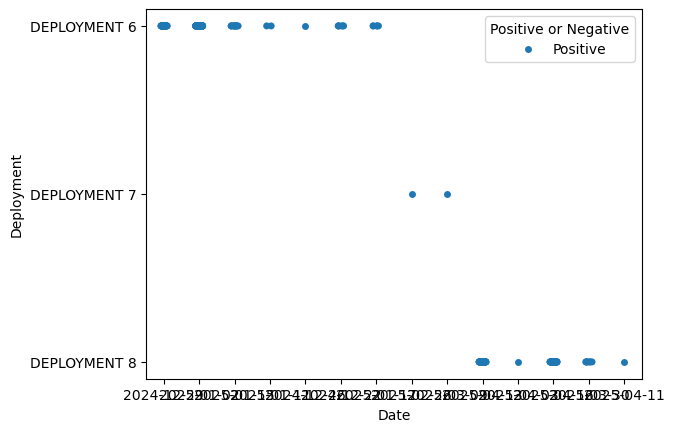

In [28]:
sns.stripplot(data=all_data, y='Deployment', hue='Positive or Negative', x='Date')

In [20]:
all_data['Hour'] = all_data['Start Time'].apply(lambda x: datetime.datetime.strptime(x, '%Y-%m-%d %H:%M:%S').hour)

<Axes: xlabel='Hour', ylabel='count'>

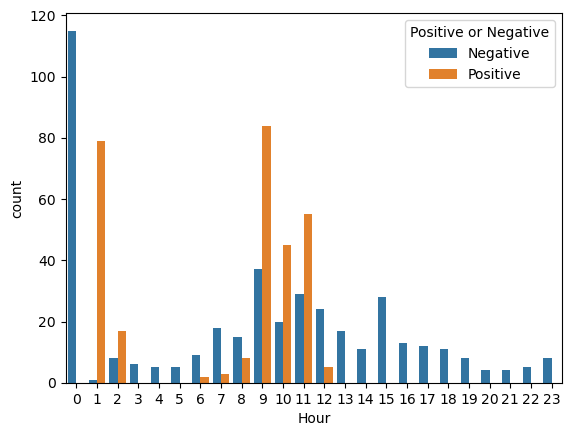

In [21]:
sns.countplot(data=all_data, x='Hour', hue='Positive or Negative')

In [69]:
data=all_data[all_data['Deployment'] == 'DEP 4']#untuk melihat spesifik deployment, silakan ganti deployment numbernya

<Axes: xlabel='Hour', ylabel='count'>

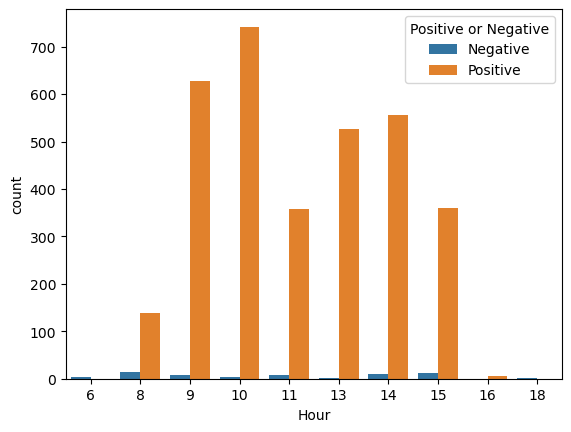

In [71]:
sns.countplot(data=data, x='Hour', hue='Positive or Negative')